In [1]:
import numpy as np
import scipy as sp
import matplotlib.colors as colors
from matplotlib.pyplot import cm

from astropy.coordinates import EarthLocation, AltAz, SkyCoord
from astropy.time import Time
import time
from scipy.integrate import simps
from time import time 
import matplotlib.animation as animation
from scan_fcts import * 
from TIM_scan_strategy import *
import importlib
from astropy.coordinates import SkyCoord
from IPython import embed
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import matplotlib.markers as mmarkers
import os
import astropy.units as u
import matplotlib
import scipy.constants as cst
# Set plot parameters
import sys

import pygetdata as gd
import numpy as np
from matplotlib.figure import Figure
from matplotlib.backends.backend_qt5agg import FigureCanvasQTAgg
from matplotlib.backends.backend_qt5agg import NavigationToolbar2QT as NavigationToolbar
from astropy.nddata import Cutout2D
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
import h5py
import os
import tracemalloc
import time
from progress.bar import Bar
import pandas as pd

import argparse

'''
matplotlib.rcParams.update({'font.size': 10})
matplotlib.rcParams.update({'xtick.direction':'in'})
matplotlib.rcParams.update({'ytick.direction':'in'})
matplotlib.rcParams.update({'xtick.top':True})
matplotlib.rcParams.update({'ytick.right':True})
matplotlib.rcParams.update({'legend.frameon':False})
matplotlib.rcParams.update({'lines.dashed_pattern':[5,3]})
'''
import pickle
from astropy.cosmology import FlatLambdaCDM
# Set cosmology to match Bolshoi-Planck simulation
cosmo = FlatLambdaCDM(H0=67.8, Om0=0.307, Ob0=0.048, Tcmb0=2.7255, Neff=3.04)
from astropy.wcs import WCS
from astropy.coordinates import Angle

from simim.lightcone import LCMaker
from simim.lightcone import LCHandler
import simim.instrument as inst
from simim.map import Gridder
from astropy. io import fits
from mpl_toolkits.axes_grid1 import make_axes_locatable
from progress.bar import Bar
from strategy import load_params

In [11]:
P = load_params('params_strategy.par')
#------------------------------------------------------------------------------------------
#Initiate the parameters

#The coordinates of the field
name=P['name_field']
c=SkyCoord.from_name(name)
ra = c.ra.value
dec = c.dec.value
#The contour of the field
contours = P['contours']
x_cen, y_cen = np.mean(contours[:, 1]), np.mean(contours[:, 0])

#load the observer position
lat = P['latitude']
lon = P['longitude']# degrees
mcmurdo = EarthLocation(lat=f'{lat}', lon=f'{lon}', height=37000.)

#Plot parameter
f_range = P['f_range']

#Load the resolution. 
#if not in params, load it from the map used to generate the TOD. 
res = P['res']
if(res is None):
    hdr = fits.getheader(P['path']+P['file'])
    res = (hdr['CDELT1'] * u.Unit(hdr['CUNIT1'])).to(u.deg).value

#Pixel offsets from the center of the field of view in degree. 
pixel_offset_HW, pixel_shift_HW = pixelOffset(P['nb_pixel_HW'], P['offset_HW'], -P['arrays_separation']/2)
pixel_offset_LW, pixel_shift_LW = pixelOffset(P['nb_pixel_LW'], P['offset_LW'], P['arrays_separation']/2) 
pixel_offset = np.concatenate((pixel_offset_HW, pixel_offset_LW))
pixel_shift  = np.concatenate((pixel_shift_HW, pixel_shift_LW)) 

#Angle of the rotation to apply to the detector array. 
theta = np.radians(P['theta'])
len(pixel_shift)

116

In [3]:
#Load the scan duration and generate the time coordinates with the desired acquisition rate. 
T_duration = P['T_duration'] 
dt = P['dt']*np.pi/3.14 #Make the timestep non rational to avoid some stripes in the hitmap. 
T = np.arange(0,T_duration,dt) * 3600
HA = 15*np.arange(-T_duration/2,T_duration/2,dt)  # hours angle

In [4]:
#----------------------------------------
#Generate the scan path for the center of the arrays. 
if(P['scan']=='loop'):   az, alt, flag = genLocalPath(az_size=P['az_size'], alt_size=P['alt_size'], alt_step=P['alt_step'], acc=P['acc'], scan_v=P['scan_v'], dt=np.round(dt*3600,3))
if(P['scan']=='raster'): az, alt, flag = genLocalPath_cst_el_scan(az_size=P['az_size'], alt_size=P['alt_size'], alt_step=P['alt_step'], acc=P['acc'], scan_v=P['scan_v'], dt=np.round(dt*3600,3))
if(P['scan']=='zigzag'): az, alt, flag = genLocalPath_cst_el_scan_zigzag(az_size=P['az_size'], alt_size=P['alt_size'], alt_step=P['alt_step'], acc=P['acc'], scan_v=P['scan_v'], dt=np.round(dt*3600,3))
scan_path, scan_flag = genScanPath(T, alt, az, flag)
scan_path = scan_path #[scan_flag==1] Use the scan flag to keep only constant scan speed part of the pointing. 
T_trim = T            #[scan_flag==1]
HA_trim = HA          #[scan_flag==1]

#Generate the pointing on the sky for the center of the arrays
scan_path_sky = genPointingPath(T_trim, scan_path, HA_trim, lat, dec, ra) 

#Generate the scan path of each pixel, as a function of their offset to the center of the arrays. 
pixel_paths  = genPixelPath(scan_path, pixel_offset, pixel_shift, theta)

#Generate the pointing on the sky of each pixel. 
pointing_paths = [genPointingPath(T_trim, pixel_path, HA_trim, lat, dec, ra) for pixel_path in pixel_paths]

#Generate the hitmap, using all the detectors. 
xedges,yedges,hit_map = binMap(pointing_paths,res=res,f_range=f_range,dec=dec,ra=ra) 

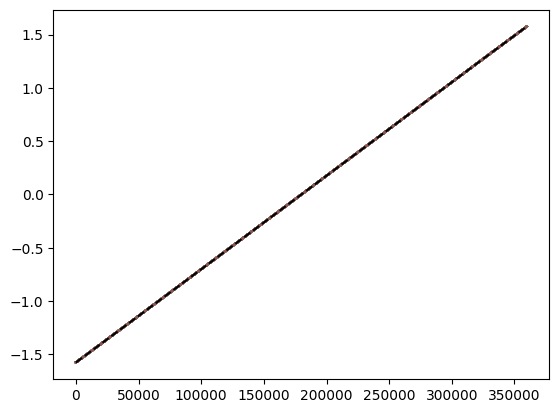

In [14]:
lat = np.ones(len(HA)) * lat
latr = np.radians(lat)
HAr = np.radians(HA)

for i in range(116):
    dec_path=pointing_paths[i][:,1]
    decr = np.radians(dec_path)
    #Parrallactic angle
    y = np.cos(latr)*np.sin(HAr)
    x = np.sin(latr)*np.cos(decr)-np.cos(HAr)*np.cos(latr)*np.sin(decr)
    PA = np.arctan(y,x)
    plt.plot(np.degrees(PA))

dec_path=scan_path_sky[:,1]
decr = np.radians(dec_path)
y = np.cos(latr)*np.sin(HAr)
x = np.sin(latr)*np.cos(decr)-np.cos(HAr)*np.cos(latr)*np.sin(decr)
PA = np.arctan(y,x)
plt.plot(np.degrees(PA), '--k')
    